# Project 3: Sentiment Analysis with RNN and LSTM



In [ ]:
import copy
import math
import random
import re
import urllib.request
import zipfile
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_sequence
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data_root = Path("data")
data_root.mkdir(exist_ok=True)

print(f"Using device: {device}")


Using device: cuda


## Download and Read the Dataset

We will use the `imdb_labelled.txt` file from the UCI Sentiment Labelled Sentences dataset.

Each row contains:

- a sentence
- a sentiment label (`0` for negative, `1` for positive)


In [ ]:
dataset_url = (
    "https://archive.ics.uci.edu/static/public/331/"
    "sentiment%2Blabelled%2Bsentences.zip"
)
archive_path = data_root / "sentiment_labelled_sentences.zip"
extract_dir = data_root / "sentiment_labelled_sentences"
dataset_files = [
    "amazon_cells_labelled.txt",
    "imdb_labelled.txt",
    "yelp_labelled.txt",
]

if not extract_dir.exists():
    urllib.request.urlretrieve(dataset_url, archive_path)
    with zipfile.ZipFile(archive_path, "r") as zf:
        zf.extractall(extract_dir)

samples = []
source_counts = {}
dataset_folder = extract_dir / "sentiment labelled sentences"

for filename in dataset_files:
    file_path = dataset_folder / filename
    file_samples = 0
    with file_path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            sentence, label = line.rsplit("	", 1)
            samples.append((sentence, int(label)))
            file_samples += 1
    source_counts[filename] = file_samples

print(f"Number of samples: {len(samples)}")
print("Samples per source:")
for filename, count in source_counts.items():
    print(f"  {filename}: {count}")
print("Example sample:")
print(samples[0])


Number of samples: 3000
Samples per source:
  amazon_cells_labelled.txt: 1000
  imdb_labelled.txt: 1000
  yelp_labelled.txt: 1000
Example sample:
('So there is no way for me to plug it in here in the US unless I go by a converter.', 0)


## Preprocess the Text

We will:

- lowercase the text
- split on words and punctuation
- build a small vocabulary
- convert each sentence into a list of token ids


In [ ]:
def tokenize(text):
    tokens = re.findall(r"[a-zA-Z']+|[.,!?;]", text.lower())
    # A few rows can become empty after regex tokenization, so we keep
    # a fallback token to make every sequence length at least 1.
    return tokens if tokens else ["<empty>"]


all_tokens = [tokenize(sentence) for sentence, _ in samples]

counter = Counter()
for tokens in all_tokens:
    counter.update(tokens)

PAD_TOKEN = "<pad>"
UNK_TOKEN = "<unk>"
stoi = {PAD_TOKEN: 0, UNK_TOKEN: 1}

for token, freq in counter.items():
    if freq >= 1:
        stoi[token] = len(stoi)

itos = {idx: token for token, idx in stoi.items()}


def encode(tokens):
    return [stoi.get(token, stoi[UNK_TOKEN]) for token in tokens]


encoded_samples = []
for (sentence, label), tokens in zip(samples, all_tokens):
    encoded = encode(tokens)
    encoded_samples.append((encoded, label))

min_length = min(len(token_ids) for token_ids, _ in encoded_samples)
max_length = max(len(token_ids) for token_ids, _ in encoded_samples)

print(f"Vocabulary size: {len(stoi)}")
print(f"First tokenized sentence: {all_tokens[0]}")
print(f"First encoded sentence: {encoded_samples[0][0]}")
print(f"Shortest encoded length: {min_length}")
print(f"Longest encoded length: {max_length}")


Vocabulary size: 5182
First tokenized sentence: ['so', 'there', 'is', 'no', 'way', 'for', 'me', 'to', 'plug', 'it', 'in', 'here', 'in', 'the', 'us', 'unless', 'i', 'go', 'by', 'a', 'converter', '.']
First encoded sentence: [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Shortest encoded length: 1
Longest encoded length: 81


## Train, Validation, and Test Split

We will shuffle the dataset and split it into:

- 70% training
- 15% validation
- 15% test


In [ ]:
random.shuffle(encoded_samples)

total_size = len(encoded_samples)
train_end = int(0.70 * total_size)
valid_end = int(0.85 * total_size)

train_samples = encoded_samples[:train_end]
valid_samples = encoded_samples[train_end:valid_end]
test_samples = encoded_samples[valid_end:]

print(f"Train size: {len(train_samples)}")
print(f"Validation size: {len(valid_samples)}")
print(f"Test size: {len(test_samples)}")


Train size: 2100
Validation size: 450
Test size: 450


In [ ]:
class SentimentDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        token_ids, label = self.samples[idx]
        return torch.tensor(token_ids, dtype=torch.long), torch.tensor(label, dtype=torch.long)


def collate_batch(batch):
    texts, labels = zip(*batch)
    lengths = torch.tensor([len(x) for x in texts], dtype=torch.long)
    padded_texts = pad_sequence(texts, batch_first=True, padding_value=stoi[PAD_TOKEN])
    labels = torch.stack(labels)
    return padded_texts, lengths, labels


batch_size = 32

train_loader = DataLoader(
    SentimentDataset(train_samples),
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_batch,
)

valid_loader = DataLoader(
    SentimentDataset(valid_samples),
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_batch,
)

test_loader = DataLoader(
    SentimentDataset(test_samples),
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_batch,
)

sample_batch = next(iter(train_loader))
print("Padded batch shape:", sample_batch[0].shape)
print("Lengths shape:", sample_batch[1].shape)
print("Labels shape:", sample_batch[2].shape)


Padded batch shape: torch.Size([32, 28])
Lengths shape: torch.Size([32])
Labels shape: torch.Size([32])


## Helper Functions

These helpers will be reused for both the RNN and the LSTM.


In [ ]:
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


def binary_accuracy_from_logits(logits, labels):
    preds = (torch.sigmoid(logits) >= 0.5).long()
    return (preds == labels).sum().item()


def train_one_epoch(model, loader, optimizer, criterion, device, epoch, epochs, model_name, grad_clip=None):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    progress = tqdm(loader, desc=f"{model_name} Train {epoch}/{epochs}", leave=False)
    for texts, lengths, labels in progress:
        texts = texts.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device).float()

        optimizer.zero_grad()
        logits = model(texts, lengths)
        loss = criterion(logits, labels)
        loss.backward()
        if grad_clip is not None:
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        total_correct += binary_accuracy_from_logits(logits, labels.long())
        total_examples += labels.size(0)

        progress.set_postfix(
            loss=f"{total_loss / total_examples:.4f}",
            acc=f"{total_correct / total_examples:.4f}",
        )

    return {
        "loss": total_loss / total_examples,
        "accuracy": total_correct / total_examples,
    }


@torch.no_grad()
def evaluate(model, loader, criterion, device, split_name, model_name):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    progress = tqdm(loader, desc=f"{model_name} {split_name}", leave=False)
    for texts, lengths, labels in progress:
        texts = texts.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device).float()

        logits = model(texts, lengths)
        loss = criterion(logits, labels)

        total_loss += loss.item() * labels.size(0)
        total_correct += binary_accuracy_from_logits(logits, labels.long())
        total_examples += labels.size(0)

        progress.set_postfix(
            loss=f"{total_loss / total_examples:.4f}",
            acc=f"{total_correct / total_examples:.4f}",
        )

    return {
        "loss": total_loss / total_examples,
        "accuracy": total_correct / total_examples,
    }


def fit(model, train_loader, valid_loader, optimizer, criterion, device, epochs, model_name, grad_clip=1.0):
    history = {
        "train_loss": [],
        "train_acc": [],
        "valid_loss": [],
        "valid_acc": [],
    }

    best_valid_acc = -1.0
    best_valid_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(1, epochs + 1):
        train_metrics = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device,
            epoch,
            epochs,
            model_name,
            grad_clip=grad_clip,
        )
        valid_metrics = evaluate(
            model,
            valid_loader,
            criterion,
            device,
            split_name="Valid",
            model_name=model_name,
        )

        history["train_loss"].append(train_metrics["loss"])
        history["train_acc"].append(train_metrics["accuracy"])
        history["valid_loss"].append(valid_metrics["loss"])
        history["valid_acc"].append(valid_metrics["accuracy"])

        is_better = (
            valid_metrics["accuracy"] > best_valid_acc
            or (
                valid_metrics["accuracy"] == best_valid_acc
                and valid_metrics["loss"] < best_valid_loss
            )
        )
        if is_better:
            best_valid_acc = valid_metrics["accuracy"]
            best_valid_loss = valid_metrics["loss"]
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss: {train_metrics['loss']:.4f} | "
            f"train acc: {train_metrics['accuracy']:.4f} | "
            f"valid loss: {valid_metrics['loss']:.4f} | "
            f"valid acc: {valid_metrics['accuracy']:.4f}"
        )

    model.load_state_dict(best_state)
    print(
        f"Restored best {model_name} checkpoint | "
        f"best valid loss: {best_valid_loss:.4f} | "
        f"best valid acc: {best_valid_acc:.4f}"
    )

    return history


def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], marker="o", label="Train")
    axes[0].plot(epochs, history["valid_loss"], marker="o", label="Validation")
    axes[0].set_title(f"{title} Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], marker="o", label="Train")
    axes[1].plot(epochs, history["valid_acc"], marker="o", label="Validation")
    axes[1].set_title(f"{title} Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


## Model 1: Simple RNN Classifier

This model uses:

- an embedding layer
- a single RNN layer
- one linear output layer

We use `pack_padded_sequence` so the model can ignore padded positions.


In [ ]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=stoi[PAD_TOKEN])
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, texts, lengths):
        embedded = self.embedding(texts)
        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, hidden = self.rnn(packed)
        logits = self.fc(hidden[-1]).squeeze(1)
        return logits


rnn_model = RNNClassifier(vocab_size=len(stoi)).to(device)
rnn_criterion = nn.BCEWithLogitsLoss()
rnn_optimizer = torch.optim.Adam(rnn_model.parameters(), lr=5e-4)

total_params, trainable_params = count_parameters(rnn_model)
print(f"RNN total parameters: {total_params:,}")
print(f"RNN trainable parameters: {trainable_params:,}")


RNN total parameters: 340,033
RNN trainable parameters: 340,033


Simple RNN Train 1/15:   0%|          | 0/66 [00:00<?, ?it/s]

Simple RNN Valid:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 01/15 | train loss: 0.6918 | train acc: 0.5333 | valid loss: 0.6859 | valid acc: 0.5489


Simple RNN Train 2/15:   0%|          | 0/66 [00:00<?, ?it/s]

Simple RNN Valid:   0%|          | 0/15 [00:00<?, ?it/s]

...

Simple RNN Valid:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 14/15 | train loss: 0.1822 | train acc: 0.9352 | valid loss: 0.7918 | valid acc: 0.7111


Simple RNN Train 15/15:   0%|          | 0/66 [00:00<?, ?it/s]

Simple RNN Valid:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 15/15 | train loss: 0.1561 | train acc: 0.9481 | valid loss: 0.8293 | valid acc: 0.7244
Restored best Simple RNN checkpoint | best valid loss: 0.8293 | best valid acc: 0.7244


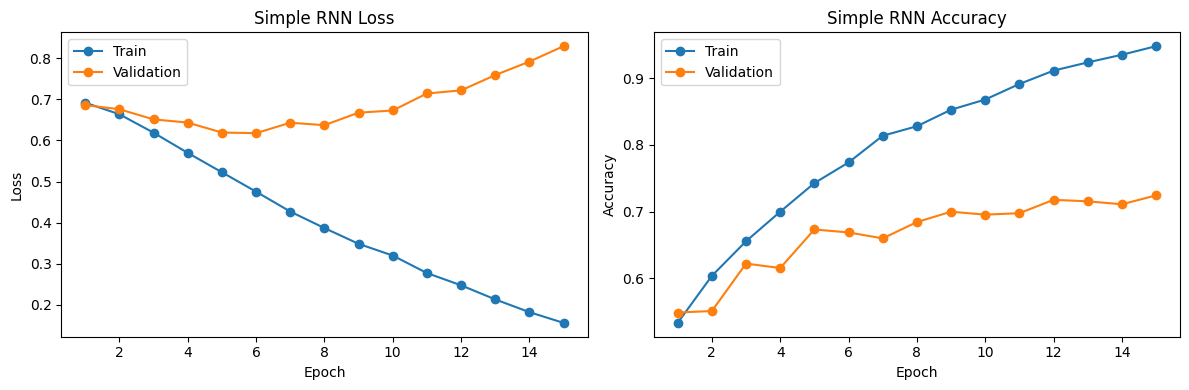

In [ ]:
RNN_EPOCHS = 15
rnn_history = fit(
    rnn_model,
    train_loader,
    valid_loader,
    rnn_optimizer,
    rnn_criterion,
    device,
    epochs=RNN_EPOCHS,
    model_name="Simple RNN",
)
plot_history(rnn_history, title="Simple RNN")


In [ ]:
rnn_test_metrics = evaluate(
    rnn_model,
    test_loader,
    rnn_criterion,
    device,
    split_name="Test",
    model_name="Simple RNN",
)

print(f"Simple RNN test loss: {rnn_test_metrics['loss']:.4f}")
print(f"Simple RNN test accuracy: {rnn_test_metrics['accuracy'] * 100:.2f}%")


Simple RNN Test:   0%|          | 0/15 [00:00<?, ?it/s]

Simple RNN test loss: 0.9459
Simple RNN test accuracy: 67.33%


## Model 2: LSTM Classifier



In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, hidden_dim=64):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=stoi[PAD_TOKEN])
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, texts, lengths):
        embedded = self.embedding(texts)
        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False,
        )
        _, (hidden, cell) = self.lstm(packed)
        logits = self.fc(hidden[-1]).squeeze(1)
        return logits


lstm_model = LSTMClassifier(vocab_size=len(stoi)).to(device)
lstm_criterion = nn.BCEWithLogitsLoss()
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=5e-4)

total_params, trainable_params = count_parameters(lstm_model)
print(f"LSTM total parameters: {total_params:,}")
print(f"LSTM trainable parameters: {trainable_params:,}")


LSTM total parameters: 364,993
LSTM trainable parameters: 364,993


LSTM Train 1/15:   0%|          | 0/66 [00:00<?, ?it/s]

LSTM Valid:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 01/15 | train loss: 0.6888 | train acc: 0.5352 | valid loss: 0.6811 | valid acc: 0.6044


LSTM Train 2/15:   0%|          | 0/66 [00:00<?, ?it/s]

LSTM Valid:   0%|          | 0/15 [00:00<?, ?it/s]

...

LSTM Valid:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 14/15 | train loss: 0.0641 | train acc: 0.9871 | valid loss: 0.9529 | valid acc: 0.7578


LSTM Train 15/15:   0%|          | 0/66 [00:00<?, ?it/s]

LSTM Valid:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 15/15 | train loss: 0.0486 | train acc: 0.9890 | valid loss: 1.0144 | valid acc: 0.7467
Restored best LSTM checkpoint | best valid loss: 0.7456 | best valid acc: 0.7711


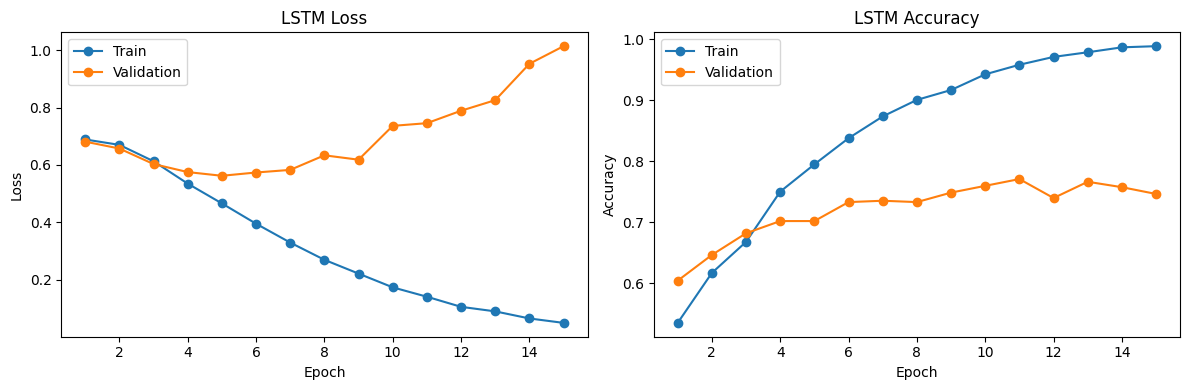

In [ ]:
LSTM_EPOCHS = 15
lstm_history = fit(
    lstm_model,
    train_loader,
    valid_loader,
    lstm_optimizer,
    lstm_criterion,
    device,
    epochs=LSTM_EPOCHS,
    model_name="LSTM",
)
plot_history(lstm_history, title="LSTM")


In [ ]:
lstm_test_metrics = evaluate(
    lstm_model,
    test_loader,
    lstm_criterion,
    device,
    split_name="Test",
    model_name="LSTM",
)

print(f"LSTM test loss: {lstm_test_metrics['loss']:.4f}")
print(f"LSTM test accuracy: {lstm_test_metrics['accuracy'] * 100:.2f}%")


LSTM Test:   0%|          | 0/15 [00:00<?, ?it/s]

LSTM test loss: 0.8032
LSTM test accuracy: 72.22%


## Compare the Models



Model                 Total Params     Trainable Params   Test Accuracy
--------------------------------------------------------------------------
Simple RNN                 340,033              340,033          70.22%
LSTM                       364,993              364,993          75.78%


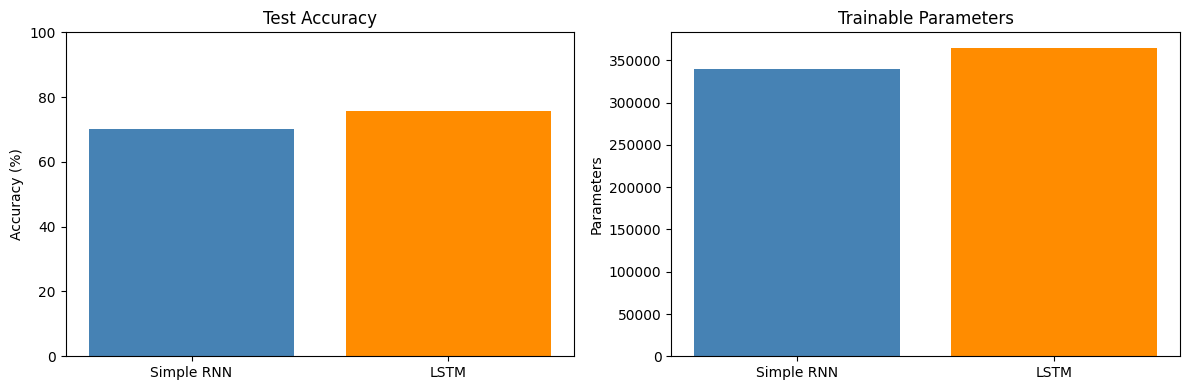

In [ ]:
comparison_rows = [
    {
        "model": "Simple RNN",
        "total_params": count_parameters(rnn_model)[0],
        "trainable_params": count_parameters(rnn_model)[1],
        "test_accuracy": rnn_test_metrics["accuracy"],
    },
    {
        "model": "LSTM",
        "total_params": count_parameters(lstm_model)[0],
        "trainable_params": count_parameters(lstm_model)[1],
        "test_accuracy": lstm_test_metrics["accuracy"],
    },
]

print(f"{'Model':18s} {'Total Params':>15s} {'Trainable Params':>20s} {'Test Accuracy':>15s}")
print("-" * 74)
for row in comparison_rows:
    print(
        f"{row['model']:18s} "
        f"{row['total_params']:15,} "
        f"{row['trainable_params']:20,} "
        f"{row['test_accuracy'] * 100:14.2f}%"
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
model_names = [row["model"] for row in comparison_rows]
accuracies = [row["test_accuracy"] * 100 for row in comparison_rows]
trainable_params = [row["trainable_params"] for row in comparison_rows]

axes[0].bar(model_names, accuracies, color=["steelblue", "darkorange"])
axes[0].set_title("Test Accuracy")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(0, 100)

axes[1].bar(model_names, trainable_params, color=["steelblue", "darkorange"])
axes[1].set_title("Trainable Parameters")
axes[1].set_ylabel("Parameters")

plt.tight_layout()
plt.show()
